In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df_index=pd.read_csv("/content/economic_index.csv")

In [ ]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
#drop col
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)

In [ ]:
df_index.isnull().sum()

,0
interest_rate,0
unemployment_rate,0
index_price,0


In [ ]:
#visualize
import seaborn as sns

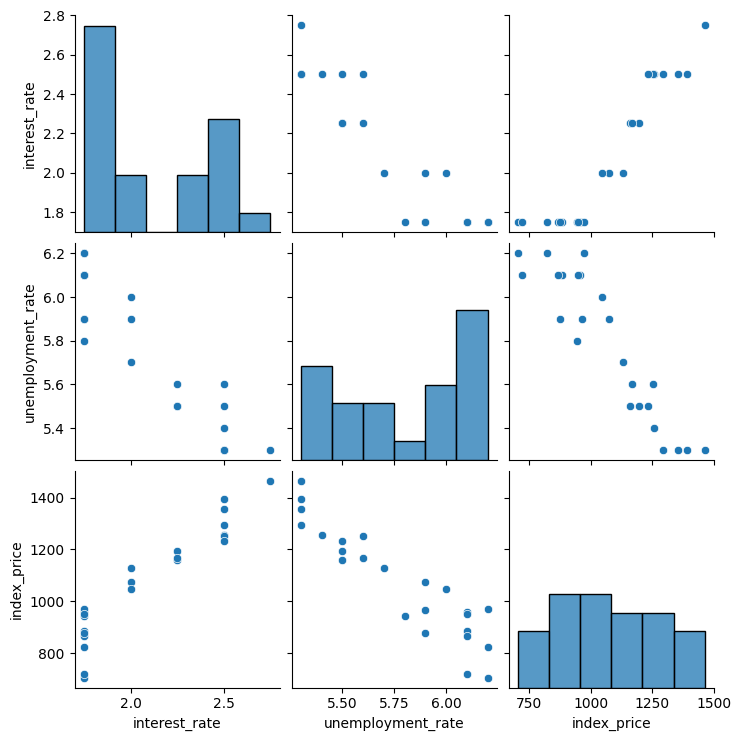

In [ ]:
sns.pairplot(df_index)

In [ ]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


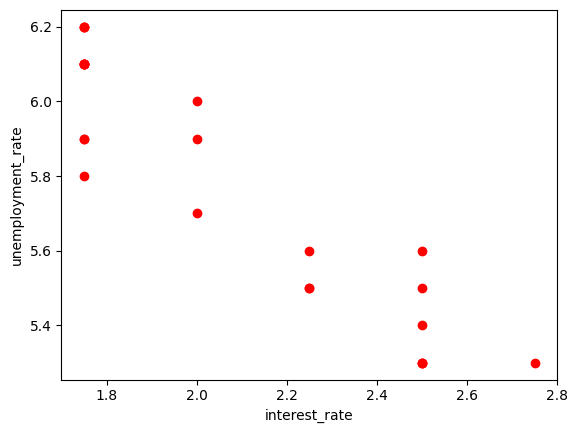

In [ ]:
#visualize datapoints more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.show()


In [ ]:
X=df_index[['interest_rate','unemployment_rate']]
y=df_index.iloc[:,-1]


In [ ]:
#train-test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

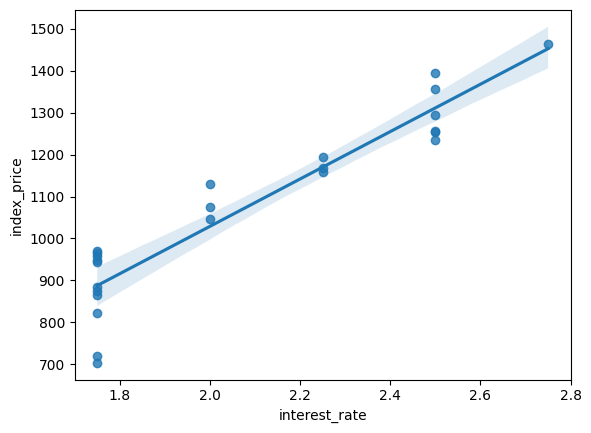

In [ ]:
sns.regplot(data=df_index, x='interest_rate', y='index_price')

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

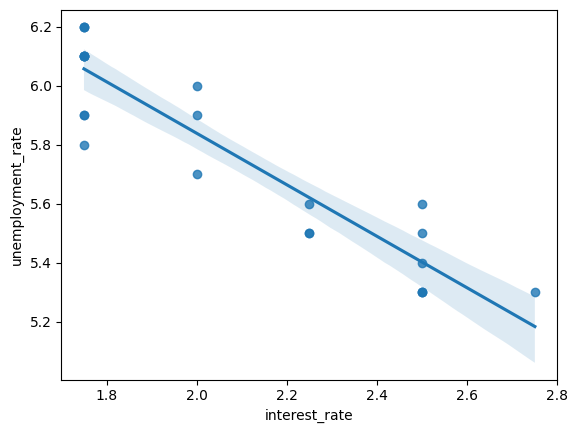

In [ ]:
sns.regplot(data=df_index, x='interest_rate', y='unemployment_rate')

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
#cross validation
from sklearn.model_selection import cross_val_score
validation=cross_val_score(regressor,X_train,y_train,scoring='neg_mean_squared_error',cv=3)


In [ ]:
np.mean(validation)

np.float64(-5914.828180162386)

In [ ]:
y_pred=regressor.predict(X_test)

In [36]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


5793.762887712569
59.935781523235484
76.11677139574805


In [37]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8278978091457145

In [ ]:
#assumptions


assumptions

Text(0, 0.5, 'y_pred')

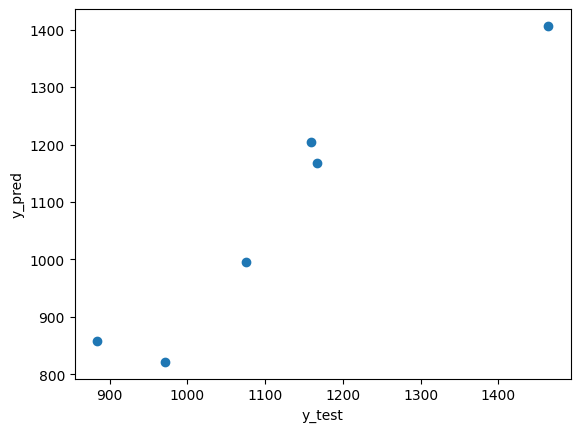

In [38]:
plt.scatter(y_test,y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')

In [40]:
residulas=y_test-y_pred
print(residulas)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


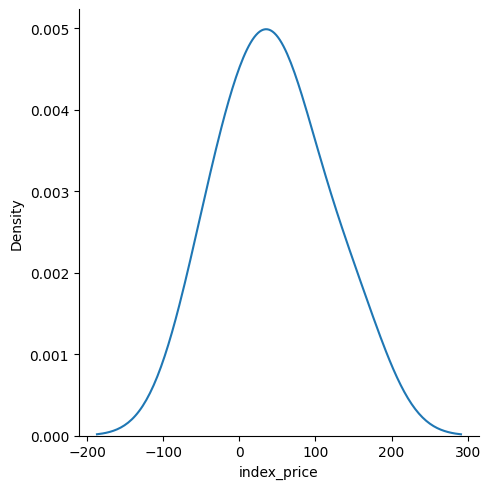

In [42]:
sns.displot(residulas,kind='kde') # model is good- normal dsitribution

In [ ]:
#scatter plot with resideuals nd prediction
plt.scatter(y_pred,residulas)
plt.xlabel('y_pred')
plt.ylabel('residulas')